## In this tutorial we're gana work on audios 

#### There are three popular format for audios:
1. mp3 :        
    - the most compress format but the smallest size
2. flac :        
    - with little compression and large size and we can reconstruct the original file with using it
3. wav :        
    - this format is without compression and it has the largest size
    
***

#### Audio signal parameters:
***
1. number of channels :
    - it can be **mono** or **stereo**, it set the number of receiving direction channels
***
2. sample width :
    - this is the number of bytes for each sample
***
3. framerate/sample_rate :
    - this is the number of samples for each second one of the standards of this parameter is 44,100 Hz and this means 44,100 samples values is received in a second 
***
4. number of frames :
     - the totall number of frames
***     
5. value of a frame :
     - when you get it its binary but we should work on it 

In [1]:
import wave

In [2]:
voice = wave.open('audio.wav', 'rb')

In [4]:
print('Number of channles:', voice.getnchannels())
print('sample width:', voice.getsampwidth())
print('Frame rate:', voice.getframerate())
print('Number of frames:', voice.getnframes())
print('parameters:', voice.getparams())

Number of channles: 2
sample width: 2
Frame rate: 44100
Number of frames: 262094
parameters: _wave_params(nchannels=2, sampwidth=2, framerate=44100, nframes=262094, comptype='NONE', compname='not compressed')


#### ! How we can get the time of the audio?

In [5]:
time_audio = voice.getnframes() / voice.getframerate()
print(time_audio)

5.9431746031746036


In [6]:
# reading total number of bytes not frames
frames_bytes = voice.readframes(-1)
print(type(frames_bytes), type(frames_bytes[0]))
print(len(frames_bytes))

<class 'bytes'> <class 'int'>
1048376


#### ! But why we have different number of bytes of frames?

In [8]:
print(len(frames_bytes)/ (voice.getsampwidth() * voice.getnchannels()))

262094.0


In [9]:
voice.close()

In [12]:
new_voice = wave.open('test_class.wav', 'wb')
new_voice.setnchannels(2)
new_voice.setsampwidth(2)
new_voice.setframerate(80000.0)
new_voice.writeframes(frames_bytes)
new_voice.close()

In [11]:
! dir

 Volume in drive A is AG
 Volume Serial Number is B219-2541

 Directory of A:\AG\AG_Science\Advanced_Python_and_Data

11/13/2025  12:25 PM    <DIR>          .
08/10/2025  05:16 PM    <DIR>          ..
10/27/2025  05:53 PM    <DIR>          .ipynb_checkpoints
05/07/2025  07:25 PM            84,868 2.jpeg
05/14/2025  04:34 PM         4,997,687 advanced_computer_vision.ipynb
10/20/2025  07:43 PM           249,761 Advanced_Pandas_Practices.ipynb
03/11/2025  07:57 PM    <DIR>          anaconda_projects
09/14/2025  06:56 PM    <DIR>          argpars_practice
08/09/2025  06:18 PM         1,048,558 audio.wav
02/20/2025  03:31 AM           273,825 choclate.csv
10/20/2025  06:10 PM           285,394 chocolate_fixed.csv
05/07/2025  07:22 PM         1,240,551 Computer_vision_tutorial.ipynb
05/06/2025  07:04 PM             9,327 cv_image.jpg
11/13/2025  02:38 AM    <DIR>          emotion_audio_wav
02/20/2025  03:31 AM             4,901 face_detection.py
11/13/2025  02:48 AM            89,649 freque

### Ploting the wav file

In [13]:
import wave 
import matplotlib.pyplot as plt
import numpy as np

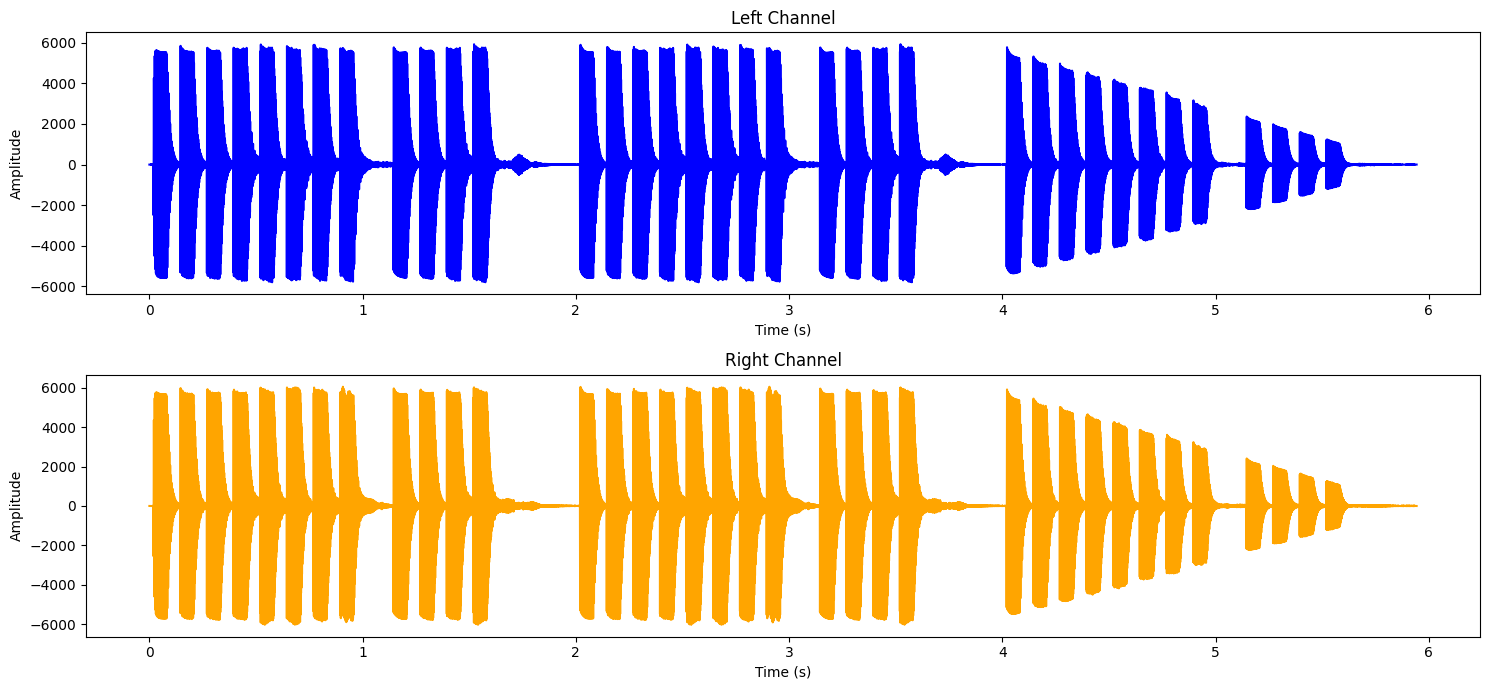

In [14]:
voice_1 = wave.open('audio.wav', 'rb')

n_channels = voice_1.getnchannels()
sample_freq = voice_1.getframerate()
n_samples = voice_1.getnframes()
signal_wave = voice_1.readframes(-1)

voice_1.close()

time_duration_1 = n_samples / sample_freq

signal_array = np.frombuffer(signal_wave, dtype=np.int16)
times = np.linspace(0, time_duration_1, num=n_samples)

# --- Handle mono or stereo ---
if n_channels > 1:
    # reshape: (n_frames, n_channels)
    signal_array = signal_array.reshape(-1, n_channels)
    left_channel = signal_array[:, 0]
    right_channel = signal_array[:, 1]
else:
    left_channel = signal_array
    right_channel = None

# --- Plot ---
plt.figure(figsize=(15, 7))

if n_channels > 1:
    plt.subplot(2, 1, 1)
    plt.plot(times, left_channel, color='blue')
    plt.title('Left Channel')
    plt.ylabel('Amplitude')
    plt.xlabel('Time (s)')
    
    plt.subplot(2, 1, 2)
    plt.plot(times, right_channel, color='orange')
    plt.title('Right Channel')
    plt.ylabel('Amplitude')
    plt.xlabel('Time (s)')
else:
    plt.plot(times, left_channel)
    plt.title('Mono Audio Signal')
    plt.ylabel('Amplitude')
    plt.xlabel('Time (s)')

plt.tight_layout()
plt.show()

In [15]:
# int16 in frombuffer make two element into one so len signal_array is 80000 whilst len signal_wave is 160000
np.set_printoptions(threshold = np.inf)
print(signal_array)
print(len(signal_array))

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [16]:
print(signal_wave)
print(len(signal_wave))

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



### Recording audio using python

1. windows :
    * pip install pyaudio
2. mac :
    * brew install portaudio
    * pip install pyaudio

In [1]:
import wave
import pyaudio

In [18]:
FORMAT = pyaudio.paInt16  # Format of audio samples (16-bit signed integers)
CHANNELS = 1              # Number of audio channels (1 for mono, 2 for stereo)
RATE = 44100              # Sample rate (samples per second)
CHUNK = 1024              # Number of frames per buffer 

p = pyaudio.PyAudio()
stream = p.open(
        format=FORMAT,
        channels=CHANNELS,
        rate=RATE,
        input=True,
        frames_per_buffer=CHUNK
)

print('start recording')

second = 7
frames = []
for i in range(0, int(RATE/CHUNK*second)):
    data = stream.read(CHUNK)
    frames.append(data)
print('finish recording')
    
stream.stop_stream()
stream.close()
p.terminate()

record = wave.open('new.wav', 'wb')
record.setnchannels(CHANNELS)
record.setsampwidth(p.get_sample_size(FORMAT))
record.setframerate(RATE)
record.writeframes(b"".join(frames))
record.close()

start recording
finish recording


### Working with audio files

1. mac :
    * brew install ffmpeg
    * pip install pydub
2. windows :
    * pip install ffmpeg
    * pip install pydub

In [2]:
from pydub import AudioSegment

In [4]:
audio = AudioSegment.from_wav('audio.wav')

# increacing the volume of the audio
audio = audio + 30
audio = audio * 2
# # Add fade in effect
audio = audio.fade_in(2000)  # 2 seconds

audio.export('new2.mp3', format = 'mp3')
audio2 = AudioSegment.from_mp3('new2.mp3')
print('done')

done


## Librosa the tool for audio processing 

LibROSA is a Python package for audio and music analysis. It provides various functions to quickly extract key audio features and metrics from your audio files. LibROSA can be used to analyze and manipulate audio files in a variety of formats such as WAV, OGG, MP3, FLAC, etc.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

from glob import glob

import librosa
import librosa.display
import IPython.display as ipd

### Terms to know for Audio in Digital Form:

#### Frequency (Hz)

- Frequency describes the differences of wave lengths.
- We interperate frequency has high and low pitches.

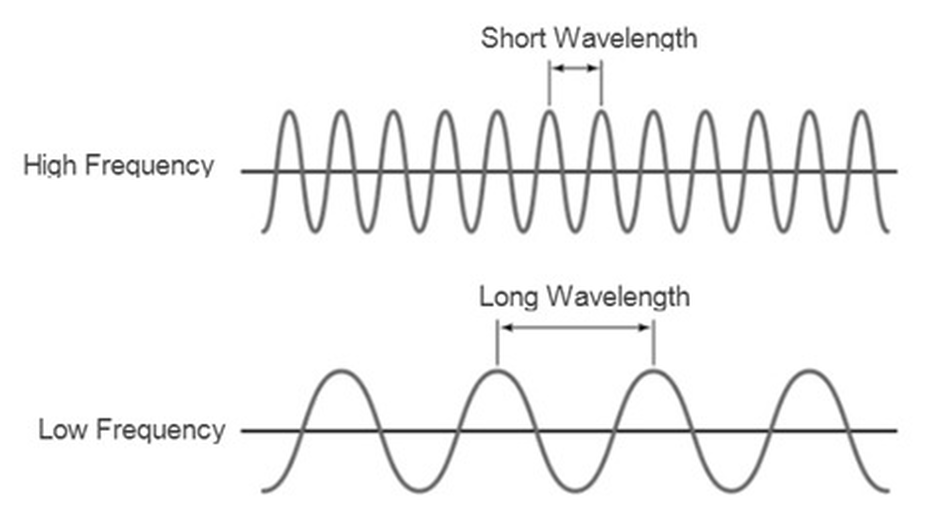

In [6]:
ipd.Image(filename='frequency_comparison.png')

#### Intensity (db / power)

- Intensity describes the amplitude (height) of the wave.

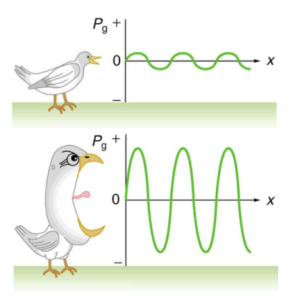

In [7]:
ipd.Image(filename='intensity.jpg')

#### Sample Rate

 - Sample rate is specific to how the computer reads in the audio file.
 - Think of it as the "resolution" of the audio.

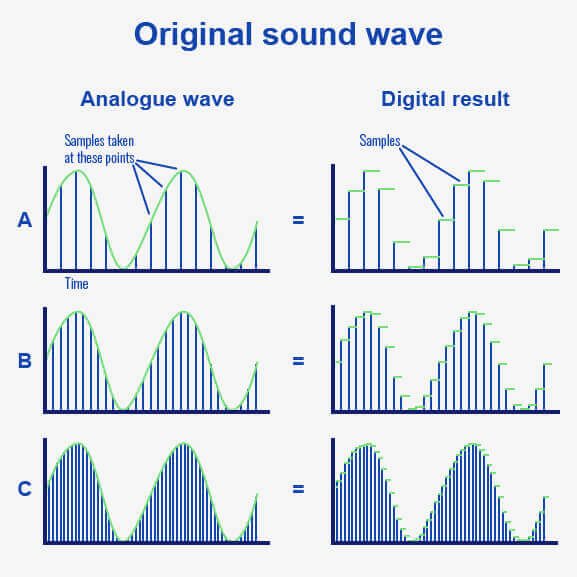

In [8]:
ipd.Image(filename='sample_rate.jpg')

In [9]:
audio_files = glob('.\emotion_audio_wav\*.wav')
audio_files

['.\\emotion_audio_wav\\03-01-03-01-01-01-15.wav',
 '.\\emotion_audio_wav\\03-01-03-01-01-01-18.wav',
 '.\\emotion_audio_wav\\03-01-04-01-01-01-10.wav',
 '.\\emotion_audio_wav\\03-01-05-01-01-01-02.wav',
 '.\\emotion_audio_wav\\03-01-05-01-01-01-13.wav',
 '.\\emotion_audio_wav\\03-01-06-01-01-01-06.wav',
 '.\\emotion_audio_wav\\03-01-06-01-01-01-11.wav']

In [11]:
# Play audio file
ipd.Audio(audio_files[2])

In [12]:
y, sr = librosa.load(audio_files[2])
print(f'y: {y[:10]}')
print(f'shape y: {y.shape}')
print(f'sr: {sr}')

y: [6.01536085e-05 1.11971960e-04 8.16483225e-05 9.00833838e-05
 1.08007909e-04 7.01144891e-05 1.19169650e-04 1.10672314e-04
 9.11479219e-05 1.10808891e-04]
shape y: (72838,)
sr: 22050


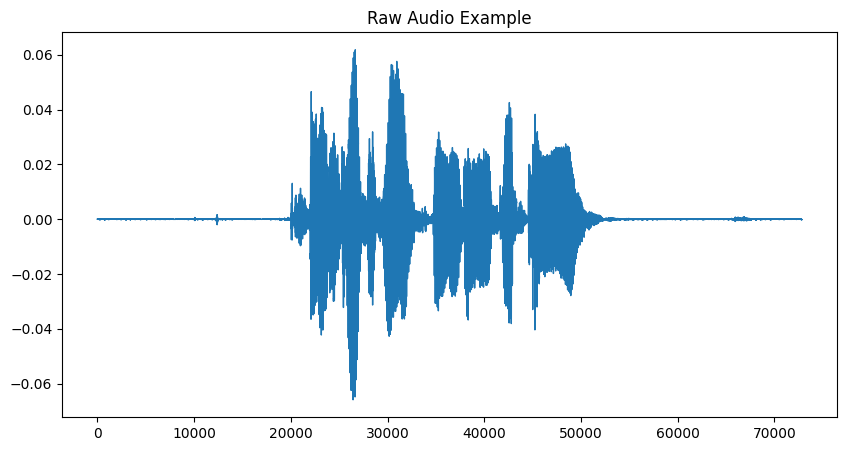

In [13]:
pd.Series(y).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Example')
plt.show()

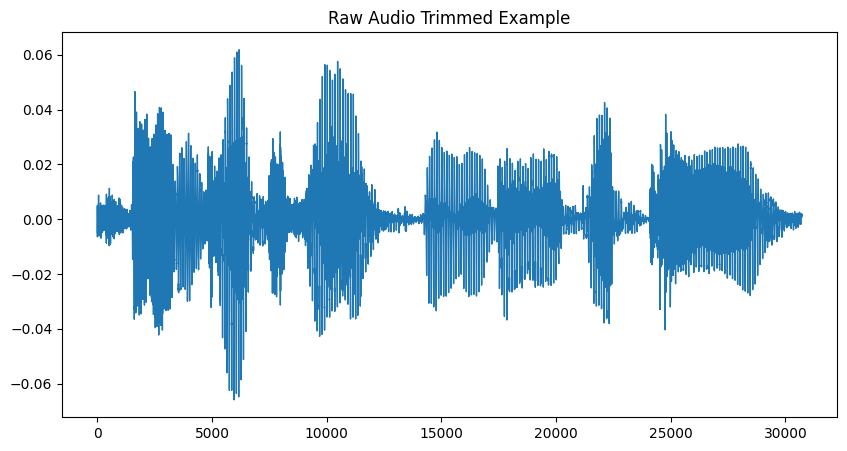

In [14]:
# top_db trim the values that are below the threshold
y_trimmed, _ = librosa.effects.trim(y, top_db=20)
pd.Series(y_trimmed).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Trimmed Example')
plt.show()

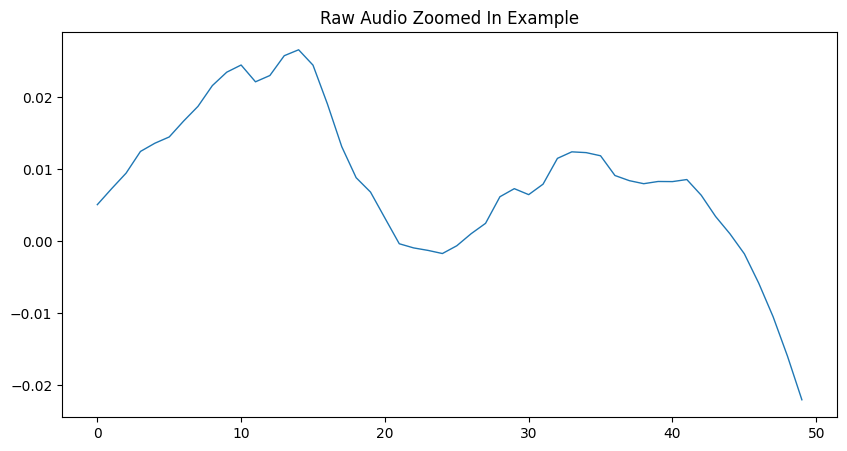

In [15]:
pd.Series(y[30000:30050]).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Zoomed In Example')
plt.show()